## Problem 4:

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [38]:
ret = pd.read_csv("48_Industry_Portfolios_Cleaned.CSV", header=0, index_col=0)


# Convert all values to numeric
ret = ret.apply(pd.to_numeric, errors='coerce')

# Handle NaN values
ret.dropna(inplace=True)  # or ret.fillna(0, inplace=True)

# Clean index (remove spaces, convert to string, ensure correct format)
ret.index = ret.index.astype(str).str.strip()

# Convert index to datetime format safely
ret.index = pd.to_datetime(ret.index, format="%Y%m", errors='coerce').to_period("M")

# Drop any rows where index conversion failed
ret.dropna(inplace=True)

# Perform division
ret = ret / 100

# Display first few rows
ret.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
1926-07,0.0237,0.0012,-0.9999,-0.0519,0.0129,0.0865,0.0250,0.5021,-0.0048,0.0808,...,0.0770,0.0192,-0.2379,0.0007,0.0187,0.0461,-0.0054,0.0289,-0.0577,0.0520
1926-08,0.0223,0.0268,-0.9999,0.2703,0.0650,0.1681,-0.0076,0.4298,-0.0358,-0.0251,...,-0.0238,0.0485,0.0539,-0.0075,-0.0013,0.1183,0.0257,0.0530,0.0032,0.0676
1926-09,-0.0057,0.0158,-0.9999,0.0402,0.0126,0.0833,0.0642,-0.0491,0.0073,-0.0051,...,-0.0554,0.0008,-0.0787,0.0025,-0.0056,-0.0175,0.0072,-0.0306,-0.0481,-0.0386
1926-10,-0.0046,-0.0368,-0.9999,-0.0331,0.0106,-0.0140,-0.0509,0.0537,-0.0468,0.0012,...,-0.0508,-0.0262,-0.1538,-0.0220,-0.0411,-0.1182,-0.0428,-0.0574,-0.0094,-0.0849
1926-11,0.0675,0.0626,-0.9999,0.0729,0.0455,0.0000,0.0182,-0.0640,-0.0054,0.0187,...,0.0384,0.0161,0.0467,0.0652,0.0433,-0.0297,0.0358,0.0221,0.0513,0.0400


In [40]:
ret.columns

Index(['Agric', 'Food ', 'Soda ', 'Beer ', 'Smoke', 'Toys ', 'Fun  ', 'Books',
       'Hshld', 'Clths', 'Hlth ', 'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls',
       'BldMt', 'Cnstr', 'Steel', 'FabPr', 'Mach ', 'ElcEq', 'Autos', 'Aero ',
       'Ships', 'Guns ', 'Gold ', 'Mines', 'Coal ', 'Oil  ', 'Util ', 'Telcm',
       'PerSv', 'BusSv', 'Comps', 'Chips', 'LabEq', 'Paper', 'Boxes', 'Trans',
       'Whlsl', 'Rtail', 'Meals', 'Banks', 'Insur', 'RlEst', 'Fin  ', 'Other'],
      dtype='object')

In [42]:
ret.columns = ret.columns.str.strip()
ret.columns

Index(['Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys', 'Fun', 'Books',
       'Hshld', 'Clths', 'Hlth', 'MedEq', 'Drugs', 'Chems', 'Rubbr', 'Txtls',
       'BldMt', 'Cnstr', 'Steel', 'FabPr', 'Mach', 'ElcEq', 'Autos', 'Aero',
       'Ships', 'Guns', 'Gold', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm',
       'PerSv', 'BusSv', 'Comps', 'Chips', 'LabEq', 'Paper', 'Boxes', 'Trans',
       'Whlsl', 'Rtail', 'Meals', 'Banks', 'Insur', 'RlEst', 'Fin', 'Other'],
      dtype='object')

<Axes: >

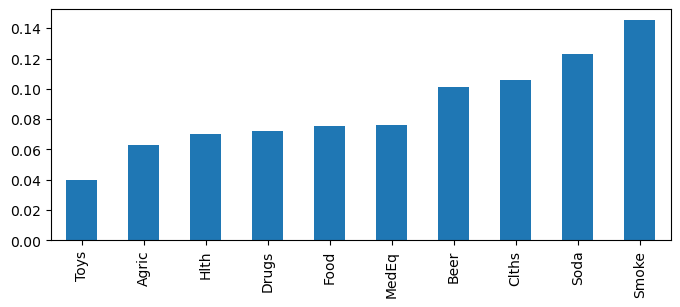

In [46]:
if isinstance(ret.index, pd.PeriodIndex):
    ret.index = ret.index.to_timestamp()

# Filter data from January 2002 onwards
ret_2002 = ret.loc["2002":]

# Select only the 10 industries of interest
selected_industries = ['Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys',
                       'Clths', 'Hlth', 'MedEq', 'Drugs']

# Ensure selected industries exist in the DataFrame
ret_2002 = ret_2002[selected_industries]

# Calculate the number of years in the dataset
n_year = ret_2002.shape[0] / 12

# Calculate annualized expected return
eret = ((1 + ret_2002).prod())**(1 / n_year) - 1

# Plot the sorted expected returns
eret.sort_values().plot.bar(figsize=(8, 3))

In [57]:
cov = ret["2002":].cov() * 12
cov.head()

,Agric,Food,Soda,Beer,Smoke,Toys,Fun,Books,Hshld,Clths,...,Boxes,Trans,Whlsl,Rtail,Meals,Banks,Insur,RlEst,Fin,Other
Agric,0.054242,0.017233,0.019167,0.014761,0.016311,0.028750,0.034343,0.032029,0.023281,0.027652,...,0.027124,0.029923,0.029180,0.027317,0.025831,0.024199,0.022514,0.033975,0.029832,0.022135
Food,0.017233,0.018629,0.017186,0.014085,0.015809,0.021450,0.022671,0.021795,0.019046,0.019933,...,0.018284,0.019834,0.019842,0.019931,0.018909,0.015797,0.016866,0.022457,0.018705,0.015309
Soda,0.019167,0.017186,0.055329,0.018477,0.017395,0.032912,0.033842,0.029538,0.024446,0.027814,...,0.022241,0.024363,0.026062,0.027801,0.025547,0.019670,0.019946,0.032488,0.025057,0.021912
Beer,0.014761,0.014085,0.018477,0.027993,0.013223,0.020016,0.021791,0.020503,0.019420,0.019651,...,0.016300,0.018286,0.018041,0.019426,0.019107,0.014604,0.015004,0.020812,0.017623,0.015431
Smoke,0.016311,0.015809,0.017395,0.013223,0.058355,0.021177,0.019778,0.020182,0.018444,0.019335,...,0.018751,0.020504,0.019023,0.018287,0.018808,0.018247,0.017382,0.023478,0.019433,0.015996


In [80]:
def port_ret(weights, ereturns):
    """
    weights + assets' exp returns --> portfolio return
    """
    return weights.T@ereturns

In [97]:
def port_vol(weights, covmat):
    """
    weights + covariance matrix --> portfolio volatility
    """
    return (weights.T@covmat@weights)**0.5

In [99]:
l = ['Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys',
    'Clths', 'Hlth', 'MedEq', 'Drugs']
eret[l]

Agric    0.062992
Food     0.075311
Soda     0.123331
Beer     0.101544
Smoke    0.145280
Toys     0.039509
Clths    0.105603
Hlth     0.070344
MedEq    0.076288
Drugs    0.072372
dtype: float64

In [101]:
cov.loc[l,l]

,Agric,Food,Soda,Beer,Smoke,Toys,Clths,Hlth,MedEq,Drugs
Agric,0.054242,0.017233,0.019167,0.014761,0.016311,0.028750,0.027652,0.028110,0.025771,0.024906
Food,0.017233,0.018629,0.017186,0.014085,0.015809,0.021450,0.019933,0.018658,0.017629,0.018298
Soda,0.019167,0.017186,0.055329,0.018477,0.017395,0.032912,0.027814,0.024019,0.022819,0.021794
Beer,0.014761,0.014085,0.018477,0.027993,0.013223,0.020016,0.019651,0.016926,0.016263,0.017651
Smoke,0.016311,0.015809,0.017395,0.013223,0.058355,0.021177,0.019335,0.019286,0.018302,0.019067
Toys,0.028750,0.021450,0.032912,0.020016,0.021177,0.086405,0.043913,0.038443,0.037839,0.035766
Clths,0.027652,0.019933,0.027814,0.019651,0.019335,0.043913,0.054944,0.032197,0.030589,0.027458
Hlth,0.028110,0.018658,0.024019,0.016926,0.019286,0.038443,0.032197,0.046251,0.033808,0.032070
MedEq,0.025771,0.017629,0.022819,0.016263,0.018302,0.037839,0.030589,0.033808,0.039847,0.036072
Drugs,0.024906,0.018298,0.021794,0.017651,0.019067,0.035766,0.027458,0.032070,0.036072,0.051197


In [103]:
w = np.repeat(.25,4)
w

array([0.25, 0.25, 0.25, 0.25])

In [105]:
print("Shape of weights:", w.shape)
print("Shape of expected returns:", eret[l].shape)


Shape of weights: (4,)
Shape of expected returns: (10,)


In [115]:
from scipy.optimize import minimize

In [126]:
def minimize_vol(target_return, ereturns, covmat):
    """
    target return ---> weights in a min-variance portfolio that generates target return 
    """
    n = ereturns.shape[0]
    init_values = np.repeat(1/n, n)
    bounds = ((0, 1),) * n 

    # Constraints:
    weights_sum_to_1 = {'type': 'eq',
                        'fun': lambda weights: np.sum(weights) - 1}
    return_is_target = {'type': 'eq',
                        'args': (ereturns,),
                        'fun': lambda weights, ereturns: port_ret(weights, ereturns) - target_return}

    results = minimize(port_vol,
                       init_values,
                       args=(covmat,),
                       method='SLSQP',
                       bounds=bounds,
                       constraints=(weights_sum_to_1, return_is_target),
                       options={'disp': False})

    weights = results.x 
    return weights # Return the optimized weights

In [128]:
wll = minimize_vol(0.11, eret[l], cov.loc[l,l])
wll

array([3.32749710e-17, 2.24427947e-01, 1.33772856e-01, 3.80478864e-01,
       2.61320333e-01, 0.00000000e+00, 3.00615619e-17, 6.31034725e-18,
       1.11938836e-17, 1.18676952e-17])

In [133]:
port_ret(wll, eret[l])

0.10999999999772192

In [136]:
def optimal_weights(n_points, ereturns, covmat):
    """
    Takes expected returns and vols + number of grid points ---> weights of efficient frontier portfolio
    """
    target_returns = np.linspace(ereturns.min(), ereturns.max(), n_points)
    opt_weights = [minimize_vol(tr, ereturns, covmat) for tr in target_returns]
    return opt_weights

<Axes: xlabel='Volatility'>

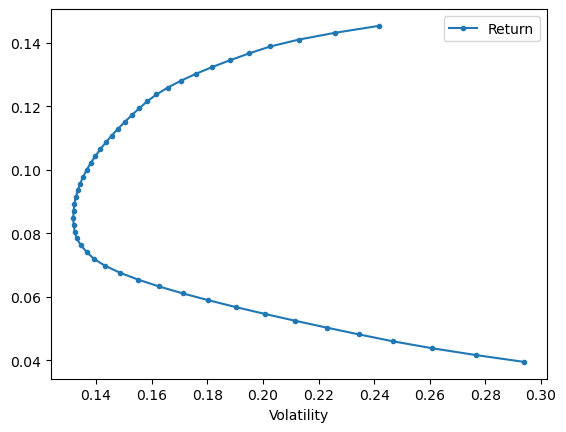

In [141]:
l = ['Agric', 'Food', 'Soda', 'Beer', 'Smoke', 'Toys',
    'Clths', 'Hlth', 'MedEq', 'Drugs']
efweights = optimal_weights(50, eret[l], cov.loc[l,l])
pret = [port_ret(w, eret[l])for w in efweights]
pvol = [port_vol(w, cov.loc[l,l])for w in efweights]
ef = pd.DataFrame({"Return": pret,"Volatility": pvol})
ef.head()
ef.plot.line(x = "Volatility",y = "Return", style = ".-")

## Problem 5:

In [145]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def portfolio_vol(weights, covmat):
    """Compute the portfolio volatility."""
    return np.sqrt(weights.T @ covmat @ weights)

def gmv(ereturns, covmat):
    """
    Compute the Global Minimum Variance (GMV) portfolio.
    
    ereturns: Expected returns of assets
    covmat: Covariance matrix of assets
    
    Returns:
    - Optimized weights for the GMV portfolio
    """
    n = ereturns.shape[0]  # Number of assets
    init_values = np.repeat(1/n, n)  # Equal initial weights
    bounds = ((0, 1),) * n  # Weights between 0 and 1

    # Constraint: Weights must sum to 1
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}

    # Minimize portfolio volatility
    results = minimize(portfolio_vol,
                       init_values,
                       args=(covmat,),
                       method='SLSQP',
                       bounds=bounds,
                       constraints=(weights_sum_to_1,),
                       options={'disp': False})

    return results.x  # Optimized weights


In [148]:
# Sample data: Replace with actual expected returns and covariance matrix
industries = ["Tech", "Finance", "Healthcare", "Energy", "Consumer Goods", 
              "Utilities", "Real Estate", "Telecom", "Materials", "Industrials"]

ereturns = np.random.rand(10) / 10  # Replace with actual expected returns
covmat = np.random.rand(10, 10)  # Replace with actual covariance matrix
covmat = (covmat + covmat.T) / 2  # Ensure symmetry (covariance matrices must be symmetric)

# Compute GMV portfolio
gmv_weights = gmv(ereturns, covmat)

# Portfolio characteristics
gmv_return = np.dot(gmv_weights, ereturns)  # Expected return of GMV portfolio
gmv_volatility = portfolio_vol(gmv_weights, covmat)  # Volatility of GMV portfolio

# Display results
gmv_results = pd.DataFrame({
    "Industry": industries,
    "Weight": gmv_weights
})

print("Global Minimum Variance Portfolio Weights:")
print(gmv_results)
print(f"\nExpected Return: {gmv_return:.4f}")
print(f"Portfolio Volatility: {gmv_volatility:.4f}")


Global Minimum Variance Portfolio Weights:
         Industry        Weight
0            Tech  9.882101e-13
1         Finance  7.933514e-13
2      Healthcare  5.640997e-13
3          Energy  3.382354e-01
4  Consumer Goods  1.802304e-11
5       Utilities  6.617646e-01
6     Real Estate  1.220427e-12
7         Telecom  5.342843e-12
8       Materials  1.762448e-11
9     Industrials  5.678298e-12

Expected Return: 0.0243
Portfolio Volatility: 0.5301


## Problem 6:

In [150]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def portfolio_ret(weights, ereturns):
    """Compute portfolio expected return."""
    return weights.T @ ereturns

def portfolio_vol(weights, covmat):
    """Compute portfolio volatility."""
    return np.sqrt(weights.T @ covmat @ weights)

def msr(ereturns, covmat, risk_free_rate=0.0):
    """
    Compute the Maximum Sharpe Ratio (MSR) portfolio.
    
    ereturns: Expected returns of assets
    covmat: Covariance matrix of assets
    risk_free_rate: Risk-free rate (default 0%)
    
    Returns:
    - Optimized weights for the MSR portfolio
    """
    n = ereturns.shape[0]  # Number of assets
    init_values = np.repeat(1/n, n)  # Equal initial weights
    bounds = ((0, 1),) * n  # Weights between 0 and 1

    
    weights_sum_to_1 = {'type': 'eq', 'fun': lambda weights: np.sum(weights) - 1}

    # Objective: Maximize Sharpe Ratio (by minimizing the negative Sharpe Ratio)
    def neg_sharpe(weights, ereturns, covmat, risk_free_rate):
        port_return = portfolio_ret(weights, ereturns)
        port_volatility = portfolio_vol(weights, covmat)
        return - (port_return - risk_free_rate) / port_volatility  # Minimize negative Sharpe Ratio


    results = minimize(neg_sharpe,
                       init_values,
                       args=(ereturns, covmat, risk_free_rate),
                       method='SLSQP',
                       bounds=bounds,
                       constraints=(weights_sum_to_1,),
                       options={'disp': False})

    return results.x  # Optimized weights


In [152]:

industries = ["Tech", "Finance", "Healthcare", "Energy", "Consumer Goods", 
              "Utilities", "Real Estate", "Telecom", "Materials", "Industrials"]

ereturns = np.random.rand(10) / 10  # Replace with actual expected returns
covmat = np.random.rand(10, 10)  # Replace with actual covariance matrix
covmat = (covmat + covmat.T) / 2  # Ensure symmetry (covariance matrices must be symmetric)


msr_weights = msr(ereturns, covmat)


msr_return = np.dot(msr_weights, ereturns)  # Expected return of MSR portfolio
msr_volatility = portfolio_vol(msr_weights, covmat)  # Volatility of MSR portfolio
msr_sharpe = msr_return / msr_volatility  # Sharpe Ratio (assuming risk-free rate = 0%)


msr_results = pd.DataFrame({
    "Industry": industries,
    "Weight": msr_weights
})

print("Maximum Sharpe Ratio Portfolio Weights:")
print(msr_results)
print(f"\nExpected Return: {msr_return:.4f}")
print(f"Portfolio Volatility: {msr_volatility:.4f}")
print(f"Sharpe Ratio: {msr_sharpe:.4f}")


Maximum Sharpe Ratio Portfolio Weights:
         Industry  Weight
0            Tech     0.0
1         Finance     0.0
2      Healthcare     0.0
3          Energy     0.0
4  Consumer Goods     0.0
5       Utilities     0.0
6     Real Estate     0.0
7         Telecom     0.0
8       Materials     1.0
9     Industrials     0.0

Expected Return: 0.0806
Portfolio Volatility: 0.2161
Sharpe Ratio: 0.3728
